In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os


import warnings
warnings.filterwarnings("ignore")



https://www.vgchartz.com/gamedb/

In [2]:
#pip install geopandas
#pip install geodatasets
#pip install cartopy

In [3]:
VGChartz = pd.read_csv("VGChartz.csv", sep=";")

In [4]:
VGChartz.head(120)

,Pos,Game,Console,Publisher,Developer,VGChartz Score,Critic Score,User Score,Total Shipped,Total Sales,NA Sales,PAL Sales,Japan Sales,Other Sales,Release Date,Last Update
0,1,1Path,And,Bulkypix,Unknown,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,02nd Mar 14,NaN
1,2,A Fistful of Gun,PC,Devolver Digital,Devolver Digital,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,01st Jul 15,NaN
2,3,Akaya Akashiya Ayakashino,PSP,Unknown,Unknown,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13th Feb 14,NaN
3,4,Akogare Girls Collection: Pika Pika Nurse Mono...,DS,Nippon Columbia,Nippon Columbia,NaN,NaN,NaN,NaN,0.02m,NaN,NaN,0.02m,NaN,10th Nov 16,03rd Aug 18
4,5,All Kamen Rider: Rider Revolution,3DS,Bandai Namco Games,Bandai Namco Games,NaN,NaN,NaN,NaN,0.06m,NaN,NaN,0.06m,NaN,01st Dec 16,06th Aug 18
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115,116,007 Legends,Mob,Activision,Eurocom,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,02nd Nov 12,16th Oct 18
116,117,007 Racing,PS,Electronic Arts,Eutechnyx,NaN,6.1,NaN,NaN,0.53m,0.30m,0.20m,NaN,0.03m,20th Nov 00,NaN
117,118,007: License To Kill,PC,Domark Software,Unknown,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,20th Apr 89,NaN
118,119,007: Quantum of Solace,PS3,Activision,Treyarch,NaN,6.6,NaN,NaN,1.14m,0.43m,0.51m,0.02m,0.19m,04th Nov 08,NaN


In [5]:
VGChartz_dropna = VGChartz.dropna(subset=['Total Shipped'])

In [6]:
length = VGChartz_dropna['Total Shipped'].size
for i in range(length):
    VGChartz_dropna['Total Shipped'].iloc[i] = VGChartz_dropna['Total Shipped'].iloc[i].replace('m', '')
    VGChartz_dropna['Total Shipped'].iloc[i] = float(VGChartz_dropna['Total Shipped'].iloc[i])

In [7]:
VGChartz_dropna = VGChartz_dropna.sort_values(by='Total Shipped')

In [8]:
VGChartz_all = VGChartz_dropna[VGChartz_dropna['Console']=='All']

In [9]:
VGChartz_all10 = VGChartz_all.tail(10)

In [10]:
VGChartz_sorted_descending=VGChartz_all10.sort_values(by='Total Shipped', ascending=False)

In [11]:
list_of_number = []
for i in range(VGChartz_sorted_descending['Total Shipped'].size):
    list_of_number.append(VGChartz_sorted_descending['Total Shipped'].iloc[i])

In [12]:
VGChartz_all10_descending = pd.DataFrame(list_of_number, index= VGChartz_sorted_descending['Game'])

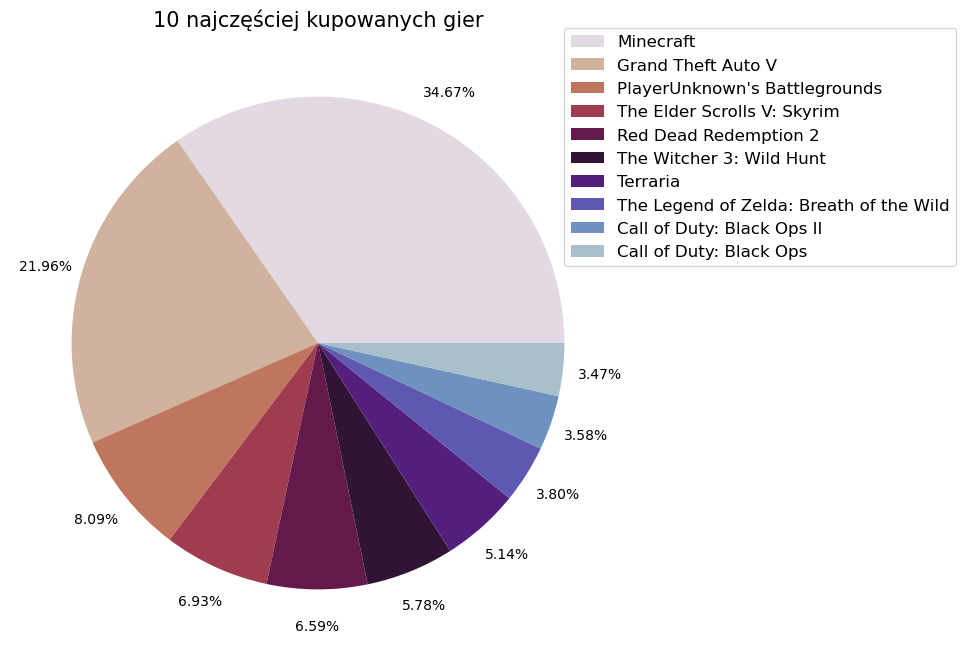

In [13]:
f, ax = plt.subplots(figsize=(14, 8))


cmap = plt.get_cmap('twilight')


num_categories = VGChartz_sorted_descending['Game'].size


colors = [cmap(1 - (i / num_categories)) for i in range(num_categories)]


for i, col in enumerate(VGChartz_all10_descending.columns):

    patches, text, _ = plt.pie(VGChartz_all10_descending[col].values, pctdistance=1.15, autopct='%.2f%%', colors=colors)

    plt.legend(loc=0, labels=VGChartz_all10_descending.index, fontsize=12, bbox_to_anchor=(0.5, 0.025, 1.05, 1))

    
plt.title('10 najczęściej kupowanych gier', fontsize=15)


plt.savefig('VGChartz_all_pie.pdf')

plt.show()

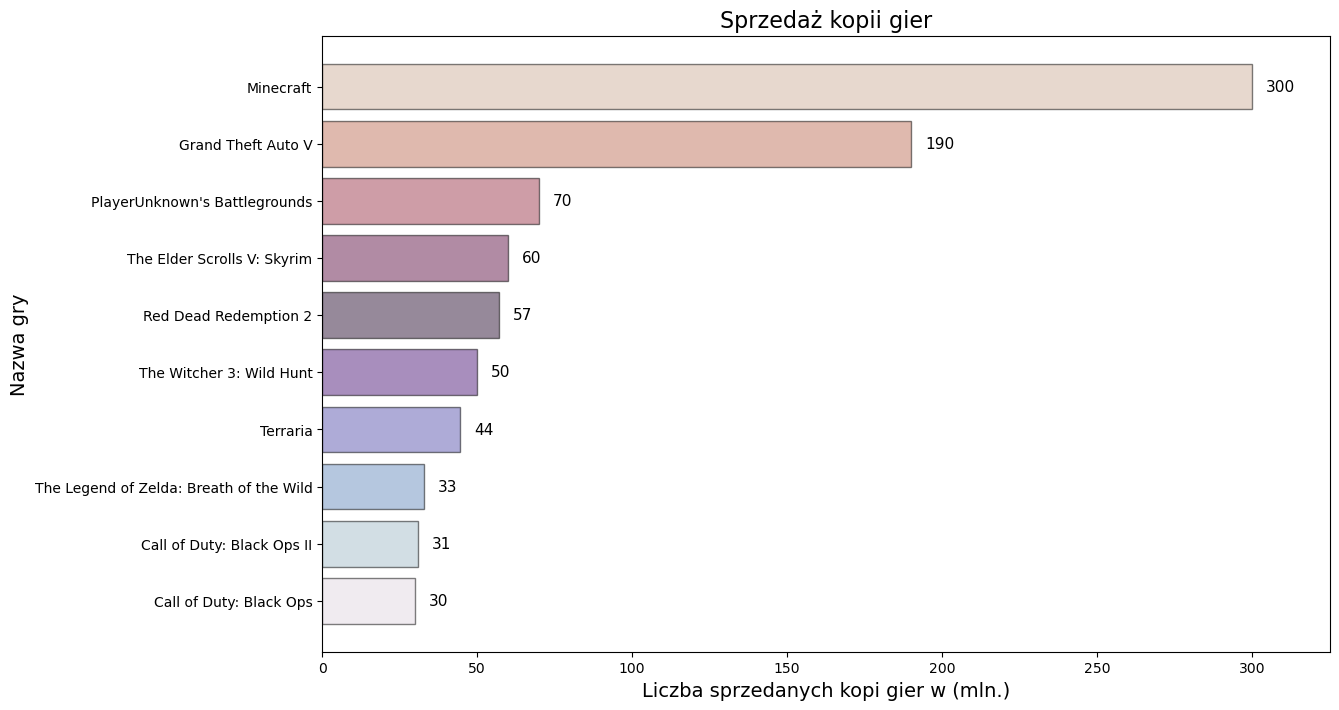

In [14]:
fig, ax = plt.subplots(figsize=(13,8))

colors_all_barh = [cmap(i / num_categories) for i in range(num_categories)]

bars = ax.barh(VGChartz_all10['Game'], VGChartz_all10['Total Shipped'], alpha=0.5, edgecolor='black', color=colors_all_barh)

for bars in ax.containers:
    ax.bar_label(bars, label_type='edge',color='black', fmt=lambda x: f'{x:.0f}', fontsize=11, padding=10)

ax.set_xlim(0,325)
ax.set_xticks([0, 50, 100, 150, 200, 250, 300])
ax.set_xlabel('Liczba sprzedanych kopi gier w (mln.)', fontsize=14)
ax.set_ylabel('Nazwa gry', fontsize=14)
ax.ticklabel_format(axis='x', style='plain', scilimits=(0,0))

plt.title('Sprzedaż kopii gier', fontsize=16)

plt.savefig('VGChartz_all_barh.pdf', bbox_inches='tight')
plt.show()

In [15]:
VGChartz_series = VGChartz_dropna[VGChartz_dropna['Console']=='Series']

In [16]:
VGChartz_series_10 = VGChartz_series.tail(10)

In [17]:
VGChartz_series_sorted_descending = VGChartz_series_10.sort_values(by='Total Shipped', ascending=False)

In [18]:
list_of_number2 = []
for i in range(VGChartz_series_sorted_descending['Total Shipped'].size):
    list_of_number2.append(VGChartz_series_sorted_descending['Total Shipped'].iloc[i])

In [19]:
VGChartz_series_sorted_descending_new = pd.DataFrame(list_of_number2, index= VGChartz_series_sorted_descending['Game'])

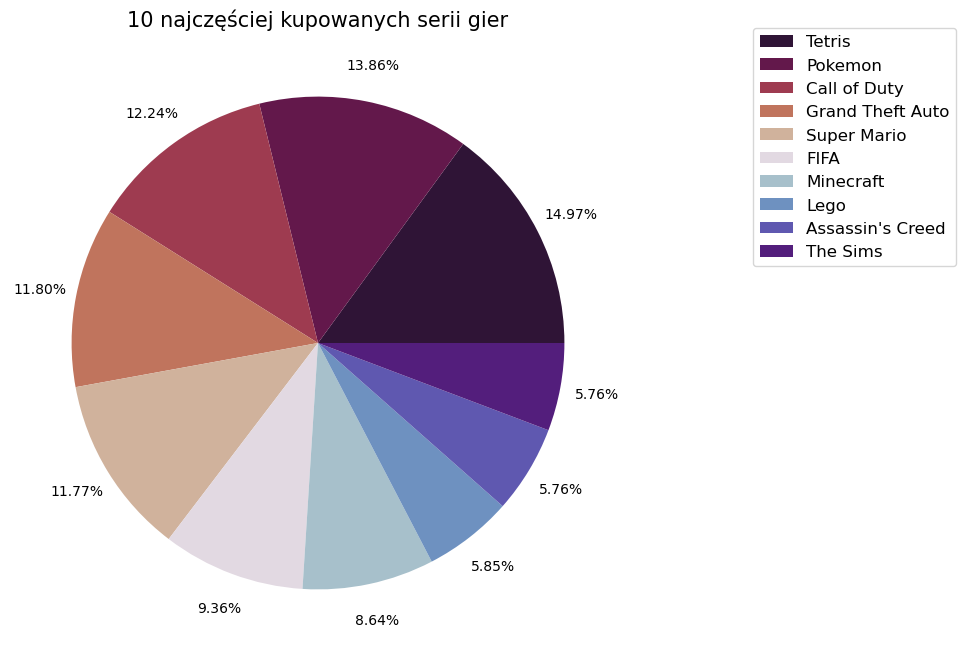

In [20]:
f, ax = plt.subplots(figsize=(14, 8))


cmap_series = plt.get_cmap('twilight_shifted')


num_categories_series = VGChartz_series_10['Game'].size


colors_series_pie = [cmap_series(1 - (i / num_categories_series)) for i in range(num_categories_series)]


for i, col in enumerate(VGChartz_series_sorted_descending_new.columns):
   
    patches, text, _ = plt.pie(VGChartz_series_sorted_descending_new[col].values, pctdistance=1.15, autopct='%.2f%%', colors=colors_series_pie)
    
    plt.legend(loc=0, labels=VGChartz_series_sorted_descending_new.index, fontsize=12, bbox_to_anchor=(0.5, 0.025, 1.05, 1))


plt.title('10 najczęściej kupowanych serii gier', fontsize=15)


plt.savefig('VGChartz_series_pie.pdf')

plt.show()

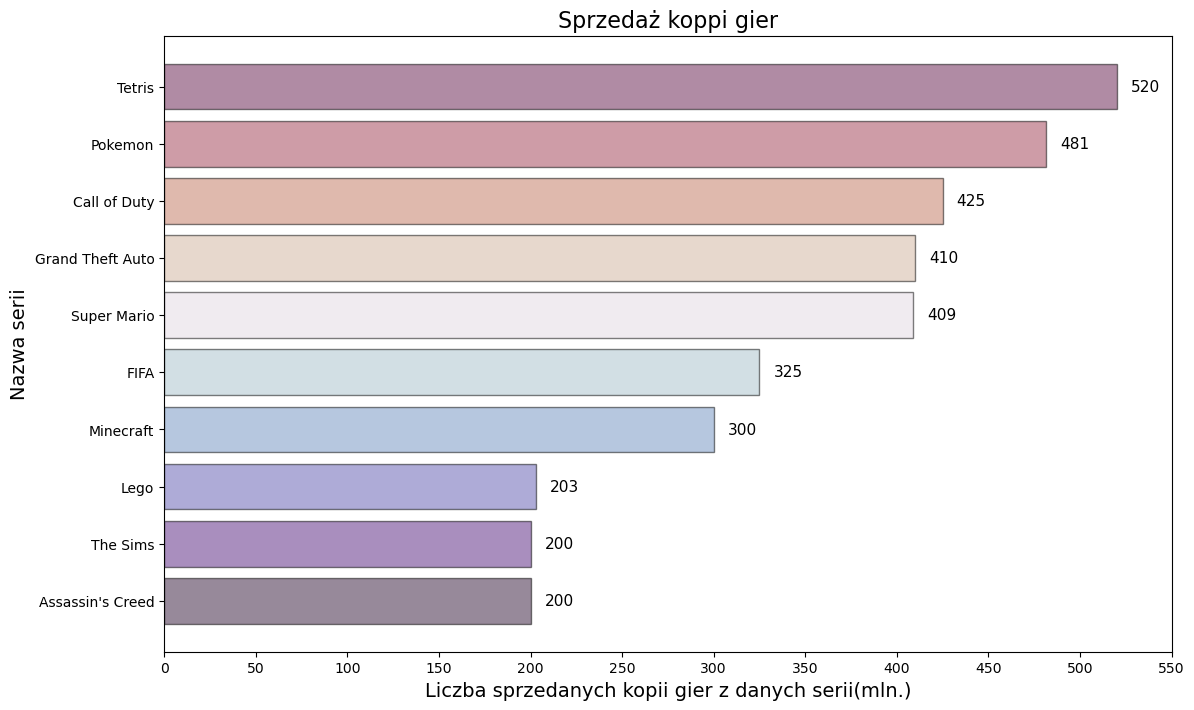

In [21]:
fig, ax = plt.subplots(figsize=(13,8))

colors_series_barh = [cmap_series(i / num_categories_series) for i in range(num_categories_series)]

bars = ax.barh(VGChartz_series_10['Game'], VGChartz_series_10['Total Shipped'], alpha=0.5, edgecolor='black', color=colors_series_barh)

for bars in ax.containers:
    ax.bar_label(bars, label_type='edge',color='black', fmt=lambda x: f'{x:.0f}', fontsize=11, padding=10)

ax.set_xlim(0,550)
ax.set_xticks([0, 50, 100, 150, 200, 250, 300, 350, 400, 450, 500,550])
ax.set_xlabel('Liczba sprzedanych kopii gier z danych serii(mln.)', fontsize=14)
ax.set_ylabel('Nazwa serii', fontsize=14)
ax.ticklabel_format(axis='x', style='plain', scilimits=(0,0))

plt.title('Sprzedaż koppi gier', fontsize=16)


plt.savefig('VGChartz_series_barh.pdf', bbox_inches='tight')
plt.show()